# Лабораторная работа 4. Сравнение моделей классификации

Цель: сравнить качество трёх моделей классификации на одном датасете:
- логистическая регрессия;
- SVM;
- дерево решений.

Дополнительно:
- построить график важности признаков для дерева решений;
- визуализировать дерево и вывести правила в текстовом виде.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import accuracy_score, f1_score, classification_report

# В этой среде sklearn иногда выбрасывает числовые RuntimeWarning при матричных операциях,
# при этом обучение и метрики считаются корректно. Убираем шум в выводе ноутбука.
warnings.filterwarnings('ignore', category=RuntimeWarning, module=r'sklearn\..*')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')

sns.set(style='whitegrid')

## 2. Выбор датасета и загрузка данных

Используем датасет `StudentsPerformance.csv`.

Задача классификации: предсказать `test preparation course` (`none` / `completed`).

In [2]:
df = pd.read_csv('StudentsPerformance.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Предобработка данных

- Проверяем пропуски;
- Кодируем категориальные признаки;
- Готовим признаки и целевую переменную.

In [3]:
print('Пропуски по столбцам:')
print(df.isna().sum())

# Целевая переменная (бинарная)
y = (df['test preparation course'] == 'completed').astype(int)

# Признаки
X = df.drop(columns=['test preparation course']).copy()

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Дополнительная защита от числовых аномалий: приводим числовые колонки к float
for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

print('\nКатегориальные признаки:', categorical_cols)
print('Числовые признаки:', numeric_cols)
print('NaN в числовых после приведения:', int(X[numeric_cols].isna().sum().sum()))

Пропуски по столбцам:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Категориальные признаки: ['gender', 'race/ethnicity', 'parental level of education', 'lunch']
Числовые признаки: ['math score', 'reading score', 'writing score']
NaN в числовых после приведения: 0


## 4. Разделение на обучающую и тестовую выборки (`train_test_split`)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (700, 7)
Test shape: (300, 7)


## 5. Обучение моделей

Обучаем:
1) логистическую регрессию;
2) SVM;
3) дерево решений.

In [5]:
# Препроцессинг для линейной модели и SVM:
# - one-hot для категориальных
# - масштабирование числовых
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='drop'
)

models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(solver='liblinear', max_iter=3000, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('prep', preprocessor),
        ('clf', SVC(kernel='rbf', probability=False, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=7, random_state=42))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained')

Logistic Regression trained
SVM (RBF) trained
Decision Tree trained


## 6. Оценка качества моделей (две метрики)

Используем:
- `Accuracy`
- `F1-score`

In [6]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'F1': f1})

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(classification_report(y_test, y_pred, digits=4))

results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
results_df


=== Logistic Regression ===
Accuracy: 0.7467
F1-score: 0.6200
              precision    recall  f1-score   support

           0     0.7826    0.8394    0.8100       193
           1     0.6667    0.5794    0.6200       107

    accuracy                         0.7467       300
   macro avg     0.7246    0.7094    0.7150       300
weighted avg     0.7413    0.7467    0.7422       300


=== SVM (RBF) ===
Accuracy: 0.7100
F1-score: 0.5246
              precision    recall  f1-score   support

           0     0.7366    0.8549    0.7914       193
           1     0.6316    0.4486    0.5246       107

    accuracy                         0.7100       300
   macro avg     0.6841    0.6518    0.6580       300
weighted avg     0.6991    0.7100    0.6962       300


=== Decision Tree ===
Accuracy: 0.6900
F1-score: 0.5507
              precision    recall  f1-score   support

           0     0.7500    0.7772    0.7634       193
           1     0.5700    0.5327    0.5507       107

    accur

,Model,Accuracy,F1
0,Logistic Regression,0.746667,0.620000
2,Decision Tree,0.690000,0.550725
1,SVM (RBF),0.710000,0.524590


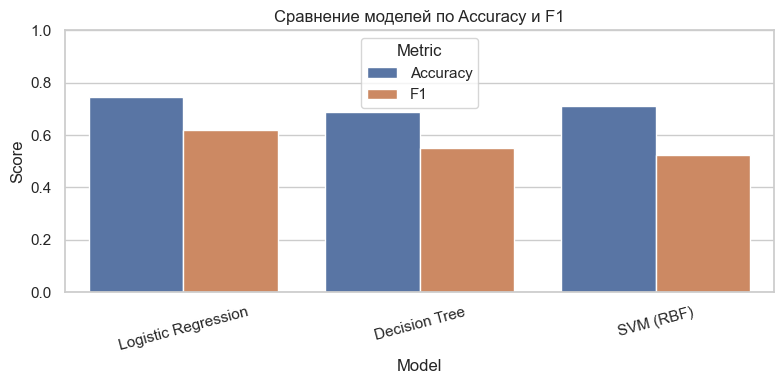

In [7]:
plt.figure(figsize=(8, 4))
plot_df = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'F1'],
                          var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title('Сравнение моделей по Accuracy и F1')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Важность признаков в дереве решений

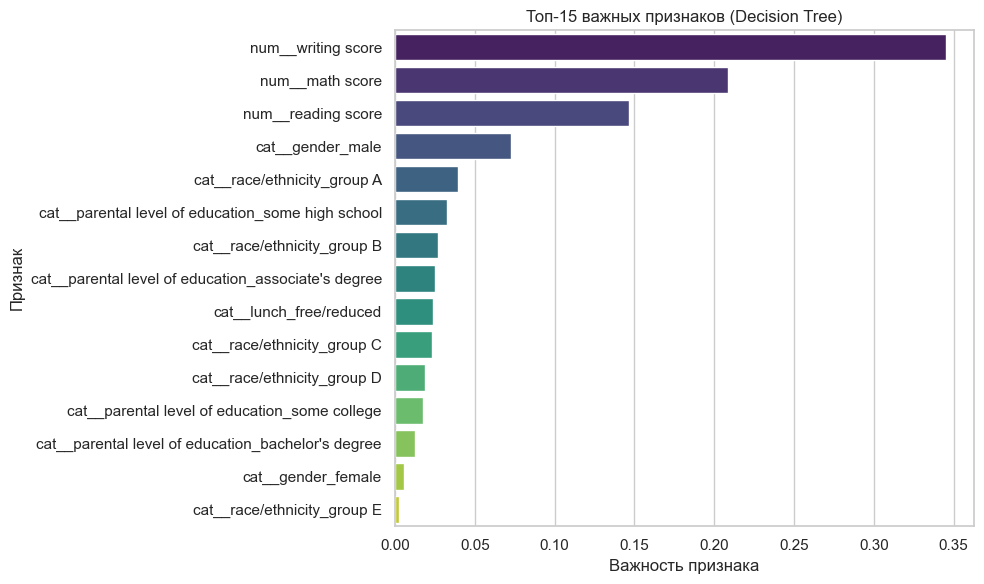

,feature,importance
17,num__writing score,0.345555
15,num__math score,0.208481
16,num__reading score,0.146604
1,cat__gender_male,0.072751
2,cat__race/ethnicity_group A,0.039253
12,cat__parental level of education_some high school,0.032572
3,cat__race/ethnicity_group B,0.026846
7,cat__parental level of education_associate's d...,0.025042
13,cat__lunch_free/reduced,0.023834
4,cat__race/ethnicity_group C,0.022881


In [8]:
tree_pipe = models['Decision Tree']
prep = tree_pipe.named_steps['prep']
tree_model = tree_pipe.named_steps['clf']

feature_names = prep.get_feature_names_out()
importances = tree_model.feature_importances_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

fi_top = fi.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_top, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Топ-15 важных признаков (Decision Tree)')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

fi_top

## 8. Визуализация дерева и правила в текстовом виде

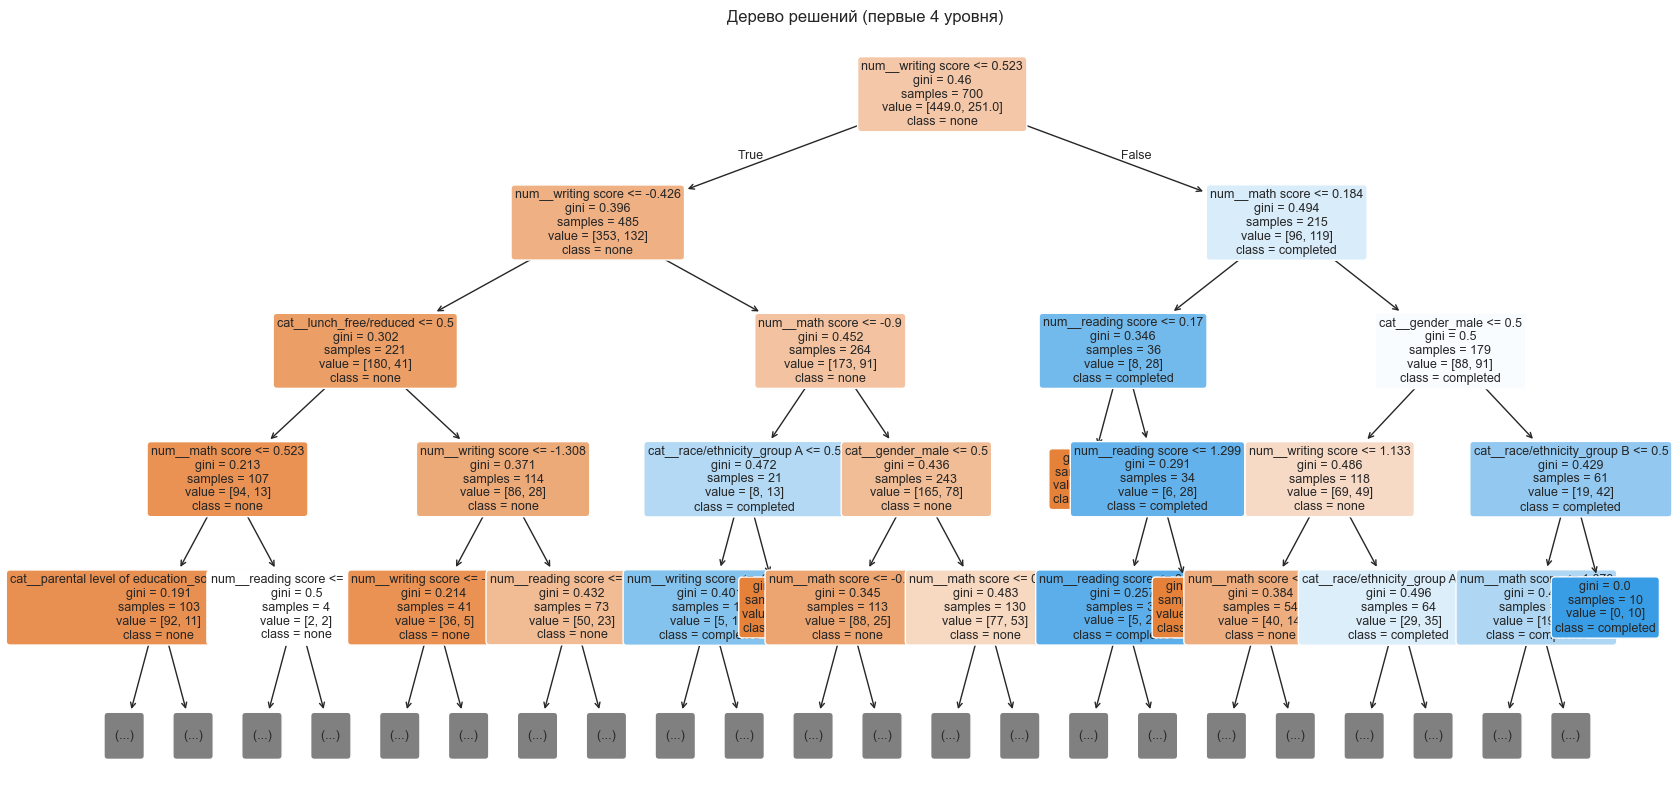

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['none', 'completed'],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)
plt.title('Дерево решений (первые 4 уровня)')
plt.show()

In [10]:
rules_text = export_text(tree_model, feature_names=list(feature_names), max_depth=3)
print('Правила дерева решений (до глубины 4):\n')
print(rules_text)

Правила дерева решений (до глубины 4):

|--- num__writing score <= 0.52
|   |--- num__writing score <= -0.43
|   |   |--- cat__lunch_free/reduced <= 0.50
|   |   |   |--- num__math score <= 0.52
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- num__math score >  0.52
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- cat__lunch_free/reduced >  0.50
|   |   |   |--- num__writing score <= -1.31
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- num__writing score >  -1.31
|   |   |   |   |--- truncated branch of depth 4
|   |--- num__writing score >  -0.43
|   |   |--- num__math score <= -0.90
|   |   |   |--- cat__race/ethnicity_group A <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- cat__race/ethnicity_group A >  0.50
|   |   |   |   |--- class: 0
|   |   |--- num__math score >  -0.90
|   |   |   |--- cat__gender_male <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- cat__gender_male >  0.50
| 

## 9. Вывод

- Подготовлены данные и выполнено разделение `train_test_split`.
- Обучены три модели: логистическая регрессия, SVM и дерево решений.
- Проведено сравнение по метрикам `Accuracy` и `F1`.
- Для дерева решений построены график важности признаков, визуализация дерева и текстовые правила.